In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_DIR = "/content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset"
TEST_DIR  = "/content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset"

import os, shutil

def make_binary_copy(src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for cls in ["Defective", "NonDefective"]:
        os.makedirs(os.path.join(dst_dir, cls), exist_ok=True)
        src_cls = os.path.join(src_dir, cls)
        if not os.path.isdir(src_cls):
            continue
        for f in os.listdir(src_cls):
            if not f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff")):
                continue
            try:
                shutil.copy(os.path.join(src_cls, f), os.path.join(dst_dir, cls, f))
            except:
                pass

BIN_TRAIN = TRAIN_DIR + "_BINARY"
BIN_TEST  = TEST_DIR + "_BINARY"

make_binary_copy(TRAIN_DIR, BIN_TRAIN)
make_binary_copy(TEST_DIR,  BIN_TEST)

print("Binary folders ready:")
print("BIN_TRAIN =", BIN_TRAIN)
print("BIN_TEST  =", BIN_TEST)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Binary folders ready:
BIN_TRAIN = /content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset_BINARY
BIN_TEST  = /content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset_BINARY


In [ ]:
import os
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt


In [ ]:
class SafeImageFolder(Dataset):
    def __init__(self, root):
        self.root = root
        self.classes = sorted(os.listdir(root))
        self.paths = []
        self.labels = []

        # Collect image paths
        for idx, cls in enumerate(self.classes):
            class_dir = os.path.join(root, cls)
            for img in os.listdir(class_dir):
                if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
                    self.paths.append(os.path.join(class_dir, img))
                    self.labels.append(idx)

        # Standard ConvNeXt transforms
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"⚠️ Skipping corrupted image: {path}")
            img = Image.new("RGB", (224,224))  # dummy fallback

        img = self.transform(img)
        return img, label


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset_BINARY"
TEST_DIR  = "/content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset_BINARY"



In [ ]:
train_ds = SafeImageFolder(TRAIN_DIR)
test_ds  = SafeImageFolder(TEST_DIR)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False)

classes = train_ds.classes
print("Classes:", classes)

Classes: ['Defective', 'NonDefective']


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

convnext = models.convnext_tiny(weights="DEFAULT")
convnext.classifier = nn.Identity()   # remove last layers
convnext = convnext.to(device)
convnext.eval()


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [ ]:
def extract_features(dataloader):
    feats = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            f = convnext(x).cpu().numpy().squeeze()
            feats.append(f)
            labels.append(y.item())

    return np.array(feats), np.array(labels)


In [ ]:
X_train, y_train = extract_features(train_loader)
X_test,  y_test  = extract_features(test_loader)

print("Feature shape:", X_train.shape)   # e.g. (2000, 768)


⚠️ Skipping corrupted image: /content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset_BINARY/Defective/translated_PPC9_06_11.png
Feature shape: (1207, 768)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
pred = rf.predict(X_test)
pred_prob = rf.predict_proba(X_test)[:,1]


In [ ]:
print(classification_report(y_test, pred, target_names=classes))


              precision    recall  f1-score   support

   Defective       0.95      1.00      0.97       170
NonDefective       1.00      0.94      0.97       147

    accuracy                           0.97       317
   macro avg       0.97      0.97      0.97       317
weighted avg       0.97      0.97      0.97       317



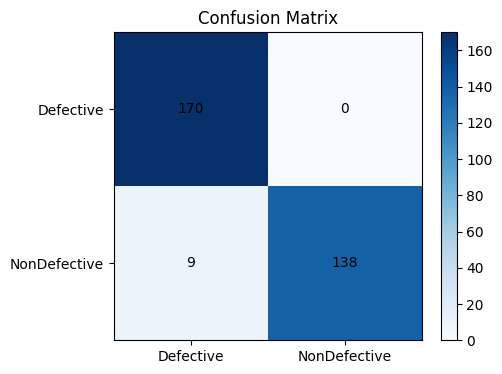

In [ ]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()


AUROC: 0.9973589435774309


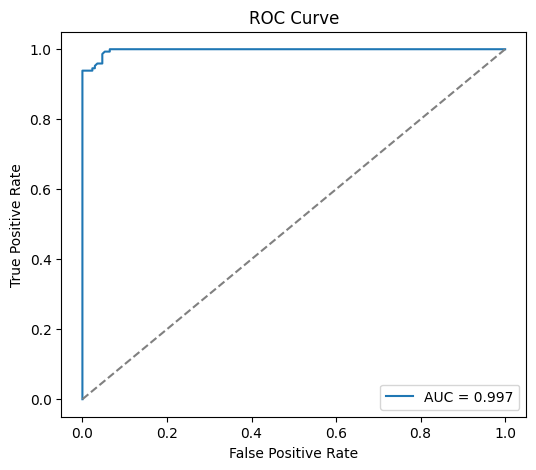

In [ ]:
fpr, tpr, _ = roc_curve(y_test, pred_prob)
roc_auc = auc(fpr, tpr)

print("AUROC:", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

overall_acc = accuracy_score(y_test, pred)
print("Overall Test Accuracy:", overall_acc)


Overall Test Accuracy: 0.9716088328075709


AUC-Precision-Recall (AUPRC): 0.9969966577502293


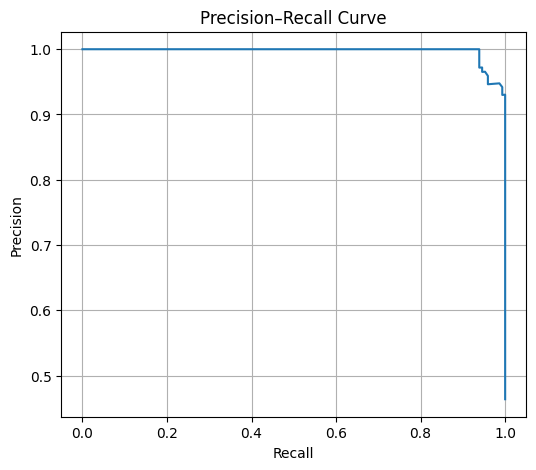

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, pred_prob)
auc_pr = average_precision_score(y_test, pred_prob)

print("AUC-Precision-Recall (AUPRC):", auc_pr)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid()
plt.show()


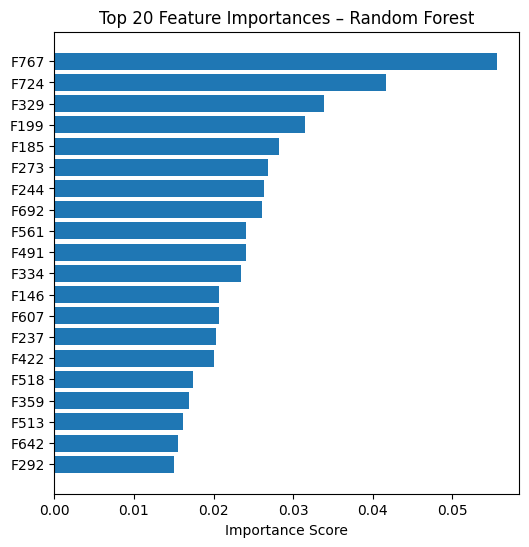

In [ ]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features

plt.figure(figsize=(6,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [f"F{i}" for i in indices])
plt.title("Top 20 Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier

surrogate = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
surrogate.fit(X_train, rf.predict(X_train))


DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

tree_fidelity = accuracy_score(rf.predict(X_test), surrogate.predict(X_test))
print("Surrogate Tree Fidelity:", tree_fidelity)


Surrogate Tree Fidelity: 0.8170347003154574


In [ ]:
import graphviz
from sklearn.tree import export_graphviz

dot_data = export_graphviz(
    surrogate,
    out_file=None,
    feature_names=[f"F{i}" for i in range(X_train.shape[1])],
    class_names=classes,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=4
)

graph = graphviz.Source(dot_data)
graph.format = "png"
graph.render("surrogate_tree")


'surrogate_tree.png'

Surrogate Fidelity (Train): 1.0
Surrogate Fidelity (Test): 0.8170347003154574


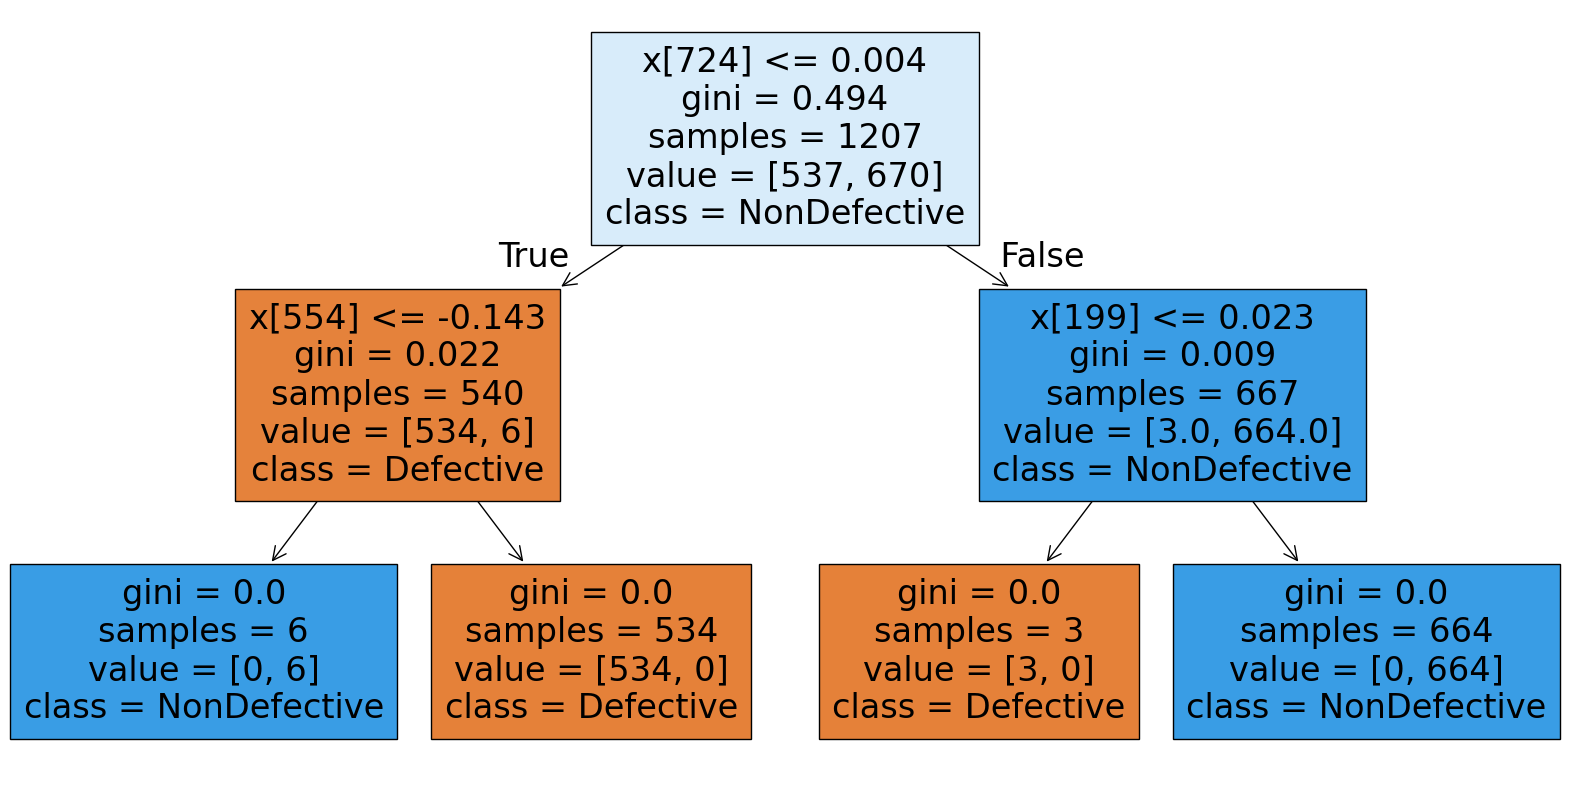

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

surrogate = DecisionTreeClassifier(max_depth=4, random_state=42)
surrogate.fit(X_train, rf.predict(X_train))

train_fidelity = surrogate.score(X_train, rf.predict(X_train))
test_fidelity  = surrogate.score(X_test,  rf.predict(X_test))

print("Surrogate Fidelity (Train):", train_fidelity)
print("Surrogate Fidelity (Test):", test_fidelity)

plt.figure(figsize=(20, 10))
plot_tree(surrogate, filled=True, class_names=classes)
plt.show()


Leaves found: [2 3 5 6]

Leaf 2: 23 test samples -> showing 4 examples


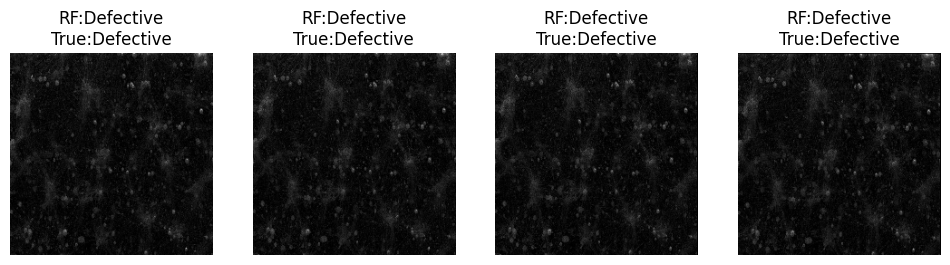


Leaf 3: 115 test samples -> showing 4 examples


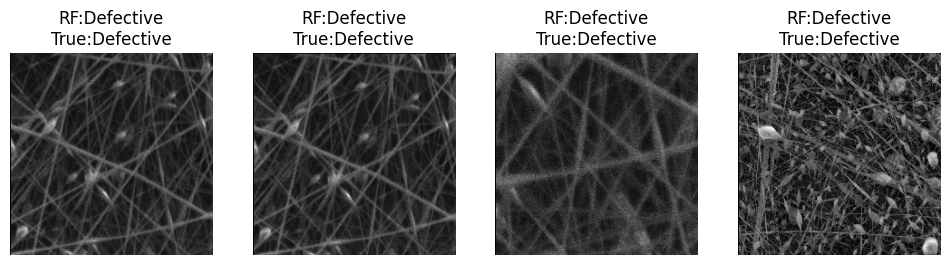


Leaf 5: 26 test samples -> showing 4 examples


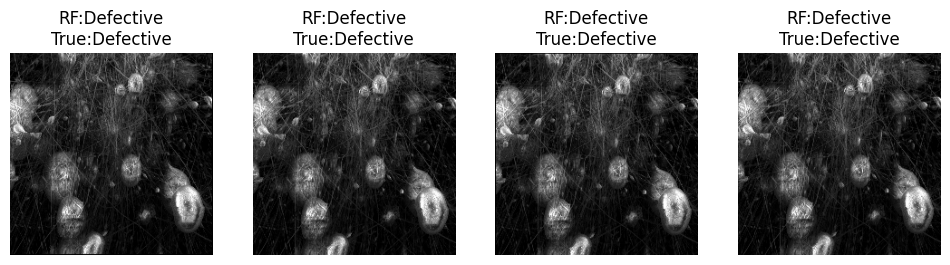


Leaf 6: 153 test samples -> showing 4 examples


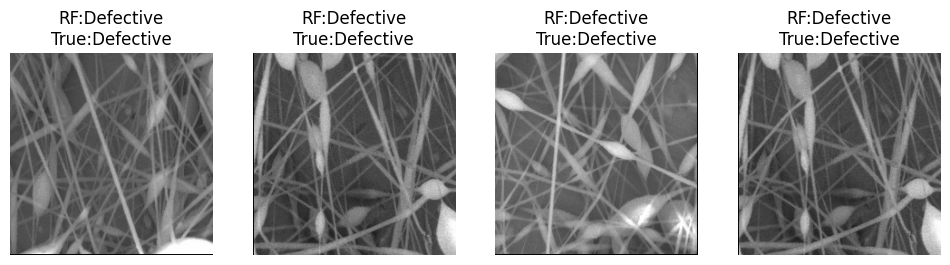

Confusion matrix: surrogate vs RF (rows: RF, cols: Surrogate):
[[131  48]
 [ 10 128]]


In [ ]:
# 5) For each leaf, show representative test images and their RF predictions
# This code block was originally part of the MobileNetV2 analysis and needed adaptation
# for the ConvNeXt analysis.

# Re-import necessary libraries if they might not be in scope in this specific cell execution context
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix

# The original X_test (raw images) was overwritten by ConvNeXt features.
# Reload the raw images for display purposes.
def load_raw_images_for_display(folder, img_size):
    images, labels = [], []
    classes_for_loading = ["Defective","NonDefective"]
    for i, cls in enumerate(classes_for_loading):
        cls_path = os.path.join(folder, cls)
        # Ensure the directory exists before listing to avoid errors on empty/missing folders
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            if not fname.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff")):
                continue
            img = cv2.imread(os.path.join(cls_path, fname))
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(i)
    return np.array(images), np.array(labels)

# Load raw test images into a new variable (X_test_original_images)
X_test_original_images, _ = load_raw_images_for_display(BIN_TEST, IMG_SIZE)


# The surrogate model was trained with ConvNeXt features (X_train).
# Apply it to ConvNeXt test features (X_test).
leaf_nodes = surrogate.apply(X_test)   # X_test now holds ConvNeXt features
unique_leaves = np.unique(leaf_nodes)
print("Leaves found:", unique_leaves)

# Helper: map leaf -> sample indices in test set
leaf_to_idxs = {leaf: np.where(leaf_nodes == leaf)[0] for leaf in unique_leaves}

# Display up to 4 representative images per leaf (showing RF prediction and true label)
max_per_leaf = 4
for leaf in unique_leaves:
    idxs = leaf_to_idxs[leaf]
    if len(idxs) == 0:
        continue
    pick = idxs[:min(max_per_leaf, len(idxs))]
    print(f"\nLeaf {leaf}: {len(idxs)} test samples -> showing {len(pick)} examples")
    # Show grid of images
    cols = len(pick)
    fig = plt.figure(figsize=(3*cols,3))
    gs = gridspec.GridSpec(1, cols)
    for i, tidx in enumerate(pick):
        ax = fig.add_subplot(gs[i])
        img = X_test_original_images[tidx] # Use the reloaded raw images
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        # Use the current RandomForest classifier 'rf' and ConvNeXt features 'X_test'
        rf_pred = rf.predict(X_test[tidx:tidx+1])[0]
        ax.set_title(f"RF:{classes[int(rf_pred)]}\nTrue:{classes[int(y_test[tidx])]}")
        ax.axis("off")
    plt.show()

# 6) Evaluate surrogate's class-wise confusion vs RF (optional)
# Recalculate rf_on_test and sur_on_test using current models and ConvNeXt features
rf_on_test = rf.predict(X_test)
sur_on_test = surrogate.predict(X_test)

cm_fidelity = confusion_matrix(rf_on_test, sur_on_test) # Renamed to avoid confusion with overall CM
print("Confusion matrix: surrogate vs RF (rows: RF, cols: Surrogate):")
print(cm_fidelity)

In [ ]:
from sklearn.metrics import (
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
    brier_score_loss
)

print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred))
print("MCC:", matthews_corrcoef(y_test, pred))
print("Cohen Kappa:", cohen_kappa_score(y_test, pred))
print("Brier Score:", brier_score_loss(y_test, pred_prob))


Balanced Accuracy: 0.9693877551020409
MCC: 0.9442322314440083
Cohen Kappa: 0.9426797661382678
Brier Score: 0.055379390115667726


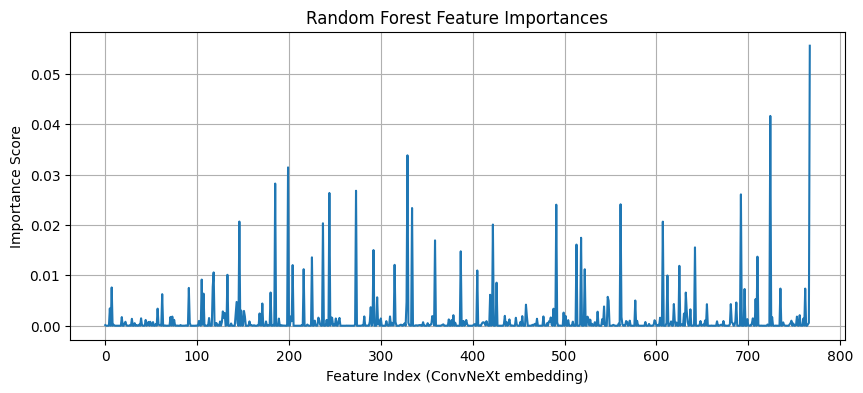

In [ ]:
importances = rf.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(importances)
plt.title("Random Forest Feature Importances")
plt.xlabel("Feature Index (ConvNeXt embedding)")
plt.ylabel("Importance Score")
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score
)

print("Overall Accuracy:", accuracy_score(y_test, pred))

# PR curve
precision, recall, thresholds = precision_recall_curve(y_test, pred_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

# MCC, Kappa, Balanced Acc
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred))
print("MCC:", matthews_corrcoef(y_test, pred))
print("Cohen Kappa:", cohen_kappa_score(y_test, pred))


Overall Accuracy: 0.9716088328075709
PR-AUC: 0.9970253081739904
Balanced Accuracy: 0.9693877551020409
MCC: 0.9442322314440083
Cohen Kappa: 0.9426797661382678


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt


In [ ]:
class SafeImageFolder(Dataset):
    def __init__(self, root):
        self.root = root
        self.classes = sorted(os.listdir(root))
        self.paths = []
        self.labels = []

        # Collect image paths
        for idx, cls in enumerate(self.classes):
            class_dir = os.path.join(root, cls)
            for img in os.listdir(class_dir):
                if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
                    self.paths.append(os.path.join(class_dir, img))
                    self.labels.append(idx)

        # Standard ConvNeXt transforms
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"⚠️ Skipping corrupted image: {path}")
            img = Image.new("RGB", (224,224))  # dummy fallback

        img = self.transform(img)
        return img, label


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset_BINARY"
TEST_DIR  = "/content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset_BINARY"



In [ ]:
train_ds = SafeImageFolder(TRAIN_DIR)
test_ds  = SafeImageFolder(TEST_DIR)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False)

classes = train_ds.classes
print("Classes:", classes)

Classes: ['Defective', 'NonDefective']


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

convnext = models.convnext_tiny(weights="DEFAULT")
convnext.classifier = nn.Identity()   # remove last layers
convnext = convnext.to(device)
convnext.eval()


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [ ]:
def extract_features(dataloader):
    feats = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            f = convnext(x).cpu().numpy().squeeze()
            feats.append(f)
            labels.append(y.item())

    return np.array(feats), np.array(labels)


In [ ]:
X_train, y_train = extract_features(train_loader)
X_test,  y_test  = extract_features(test_loader)

print("Feature shape:", X_train.shape)   # e.g. (2000, 768)


⚠️ Skipping corrupted image: /content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset_BINARY/Defective/translated_PPC9_06_11.png
⚠️ Skipping corrupted image: /content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset_BINARY/NonDefective/translated_pancnt2_04_34.tif
Feature shape: (1207, 768)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
pred = rf.predict(X_test)
pred_prob = rf.predict_proba(X_test)[:,1]


In [ ]:
print(classification_report(y_test, pred, target_names=classes))


              precision    recall  f1-score   support

   Defective       0.94      1.00      0.97       170
NonDefective       1.00      0.93      0.96       147

    accuracy                           0.97       317
   macro avg       0.97      0.97      0.97       317
weighted avg       0.97      0.97      0.97       317



In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

# Reload ConvNeXt with classifier
convnext = models.convnext_tiny(weights="DEFAULT")
convnext.classifier[2] = torch.nn.Linear(768, 2)  # binary classes
convnext = convnext.to(device)
convnext.eval()


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

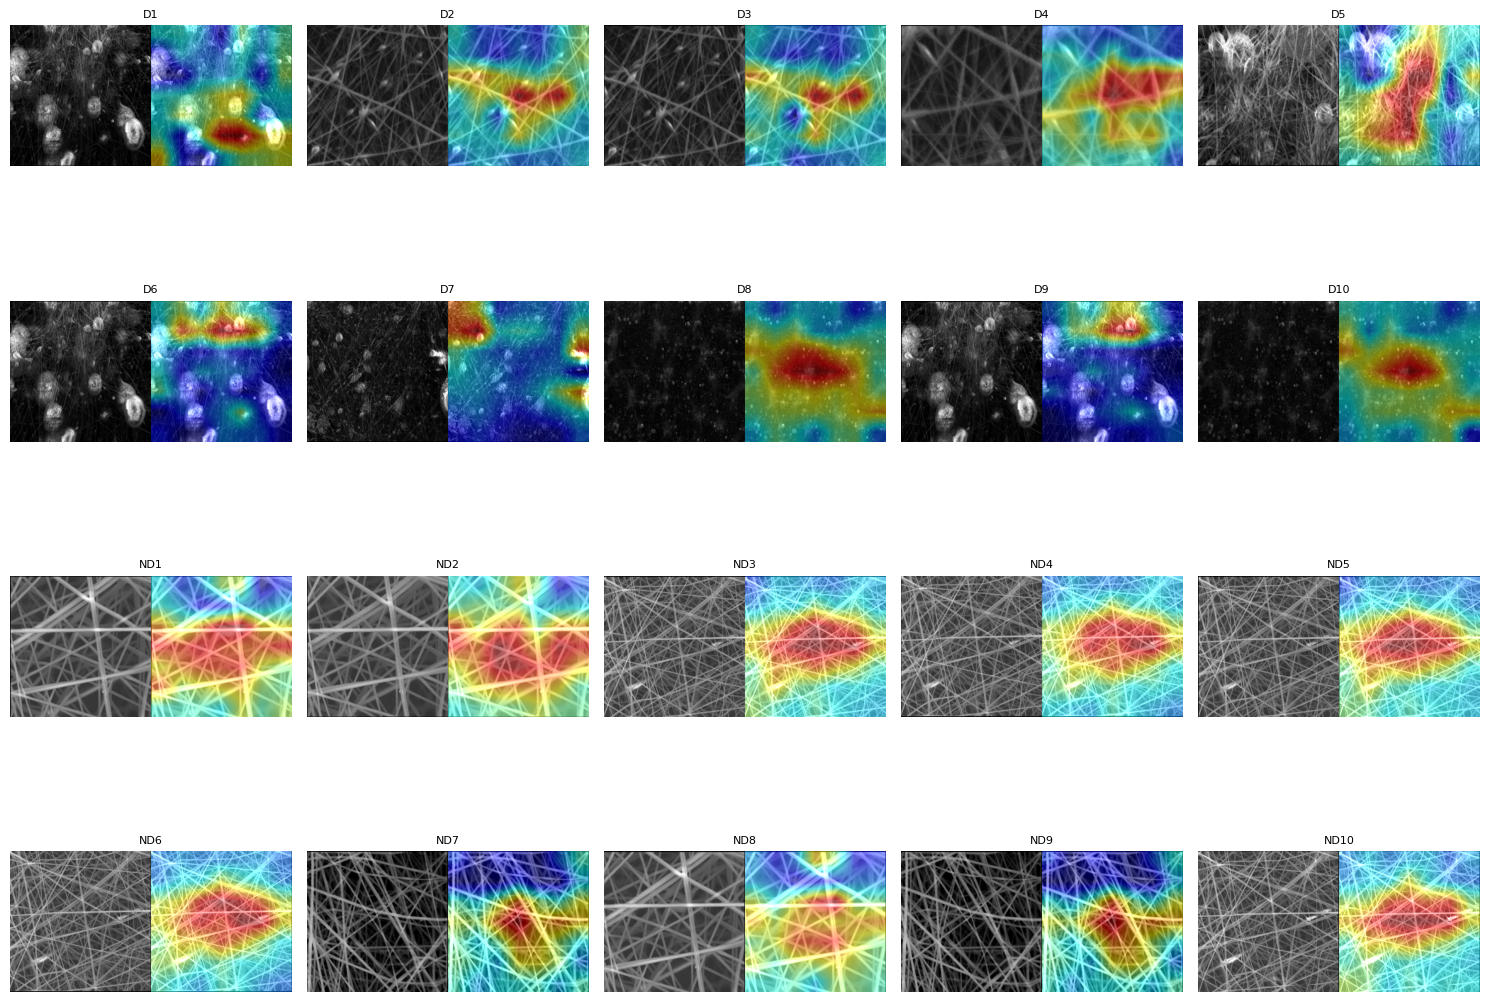

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models

# -------------------- Settings --------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
TEST_DIR = "/content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset_BINARY"

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# Load ConvNeXt
convnext = models.convnext_tiny(weights="DEFAULT")
convnext.classifier = torch.nn.Identity()
convnext = convnext.to(device)
convnext.eval()

# -------------------- Grad-CAM --------------------
activations, gradients = [], []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer = convnext.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

def generate_gradcam(img_path, class_idx=None):
    activations.clear()
    gradients.clear()

    img_pil = Image.open(img_path).convert("RGB")
    img_pil = img_pil.resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil)

    x = transform(img_pil).unsqueeze(0).to(device)
    x.requires_grad = True

    output = convnext(x)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    convnext.zero_grad()
    loss = output[0, class_idx]
    loss.backward()

    act = activations[0].squeeze(0).cpu().detach().numpy()
    grad = gradients[0].squeeze(0).cpu().detach().numpy()

    weights = np.mean(grad, axis=(1,2))
    cam = np.zeros(act.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    return img_np, cam

# -------------------- Helper --------------------
def get_n_images(folder, n=10):
    imgs = [os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff"))]
    return imgs[:n]

# -------------------- Grid Plot: Original + Grad-CAM --------------------
def plot_original_gradcam_grid(defective_imgs, nondefective_imgs, ncols=5):
    all_imgs = defective_imgs + nondefective_imgs
    all_titles = [f"D{i+1}" for i in range(len(defective_imgs))] + \
                 [f"ND{i+1}" for i in range(len(nondefective_imgs))]

    n_images = len(all_imgs)
    nrows = (n_images + ncols - 1) // ncols

    plt.figure(figsize=(ncols*3, nrows*3))  # slightly bigger to fit pairs

    for i, img_path in enumerate(all_imgs):
        img, cam = generate_gradcam(img_path)
        heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = 0.5*heatmap + img
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)

        # Each image: Original left, Grad-CAM right
        ax1 = plt.subplot(nrows, ncols, i+1)
        combined = np.concatenate([img, overlay], axis=1)  # horizontal concat
        ax1.imshow(combined)
        ax1.set_title(all_titles[i], fontsize=8)
        ax1.axis("off")

    plt.tight_layout()
    plt.show()

# -------------------- Run --------------------
defective_imgs = get_n_images(os.path.join(TEST_DIR, "Defective"), n=10)
nondefective_imgs = get_n_images(os.path.join(TEST_DIR, "NonDefective"), n=10)

plot_original_gradcam_grid(defective_imgs, nondefective_imgs, ncols=5)


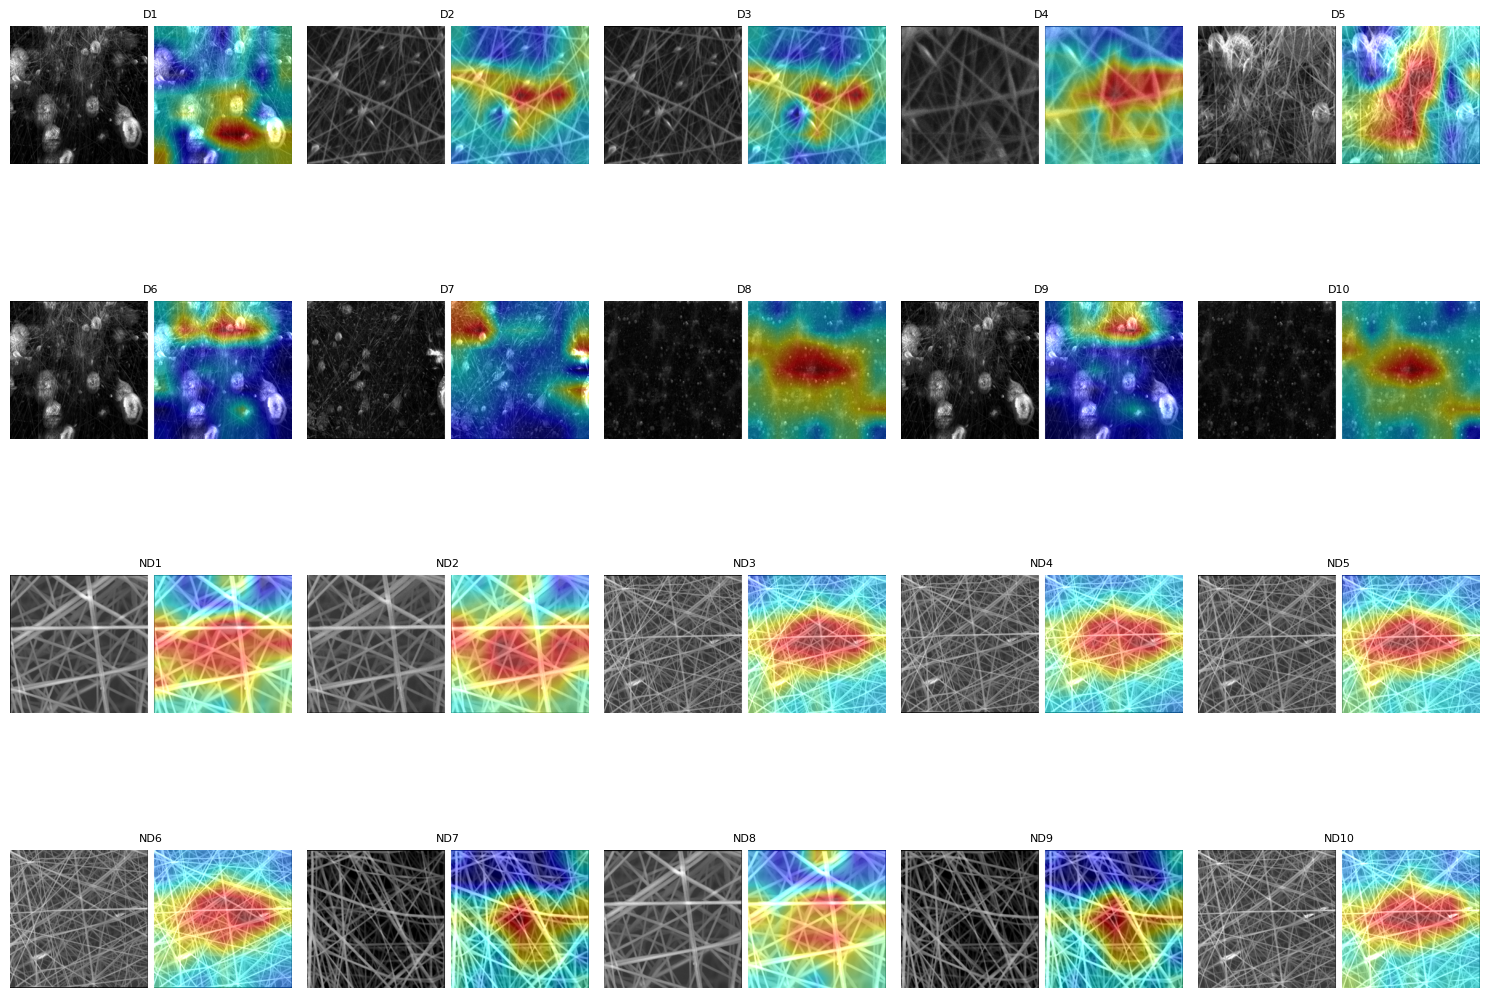

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models

# -------------------- Settings --------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
TEST_DIR = "/content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset_BINARY"

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# Load ConvNeXt
convnext = models.convnext_tiny(weights="DEFAULT")
convnext.classifier = torch.nn.Identity()
convnext = convnext.to(device)
convnext.eval()

# -------------------- Grad-CAM --------------------
activations, gradients = [], []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer = convnext.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

def generate_gradcam(img_path, class_idx=None):
    activations.clear()
    gradients.clear()

    img_pil = Image.open(img_path).convert("RGB")
    img_pil = img_pil.resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil)

    x = transform(img_pil).unsqueeze(0).to(device)
    x.requires_grad = True

    output = convnext(x)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    convnext.zero_grad()
    loss = output[0, class_idx]
    loss.backward()

    act = activations[0].squeeze(0).cpu().detach().numpy()
    grad = gradients[0].squeeze(0).cpu().detach().numpy()

    weights = np.mean(grad, axis=(1,2))
    cam = np.zeros(act.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    return img_np, cam

# -------------------- Helper --------------------
def get_n_images(folder, n=10):
    imgs = [os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff"))]
    return imgs[:n]

# -------------------- Grid Plot: Original + Grad-CAM --------------------
def plot_gradcam_grid_with_gap(defective_imgs, nondefective_imgs, ncols=5, gap=10):
    all_imgs = defective_imgs + nondefective_imgs
    all_titles = [f"D{i+1}" for i in range(len(defective_imgs))] + \
                 [f"ND{i+1}" for i in range(len(nondefective_imgs))]

    n_images = len(all_imgs)
    nrows = (n_images + ncols - 1) // ncols

    plt.figure(figsize=(ncols*3, nrows*3))

    for i, img_path in enumerate(all_imgs):
        img, cam = generate_gradcam(img_path)
        heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = 0.5*heatmap + img
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)

        # Add gap: create blank canvas slightly bigger than image
        canvas = 255 * np.ones((IMG_SIZE, IMG_SIZE*2 + gap, 3), dtype=np.uint8)
        canvas[:, :IMG_SIZE, :] = img
        canvas[:, IMG_SIZE + gap:, :] = overlay

        ax = plt.subplot(nrows, ncols, i+1)
        ax.imshow(canvas)
        ax.set_title(all_titles[i], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# -------------------- Run --------------------
defective_imgs = get_n_images(os.path.join(TEST_DIR, "Defective"), n=10)
nondefective_imgs = get_n_images(os.path.join(TEST_DIR, "NonDefective"), n=10)

plot_gradcam_grid_with_gap(defective_imgs, nondefective_imgs, ncols=5, gap=10)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_DIR = "/content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset"
TEST_DIR  = "/content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset"
IMG_SIZE = 224


Mounted at /content/drive


In [ ]:
import os, shutil

def make_binary_copy(src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for cls in ["Defective", "NonDefective"]:
        os.makedirs(os.path.join(dst_dir, cls), exist_ok=True)
        src_cls = os.path.join(src_dir, cls)
        if not os.path.isdir(src_cls):
            continue
        for f in os.listdir(src_cls):
            if not f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff")):
                continue
            try:
                shutil.copy(os.path.join(src_cls, f), os.path.join(dst_dir, cls, f))
            except:
                pass

BIN_TRAIN = TRAIN_DIR + "_BINARY"
BIN_TEST  = TEST_DIR + "_BINARY"

make_binary_copy(TRAIN_DIR, BIN_TRAIN)
make_binary_copy(TEST_DIR,  BIN_TEST)

# Quick count
for d in [BIN_TRAIN, BIN_TEST]:
    print("\nFolder:", d)
    for cls in ["Defective","NonDefective"]:
        n = len(os.listdir(os.path.join(d, cls)))
        print(f"  {cls}: {n}")



Folder: /content/drive/MyDrive/Nanofiber SEM Dataset/TrainingDataset_BINARY
  Defective: 537
  NonDefective: 670

Folder: /content/drive/MyDrive/Nanofiber SEM Dataset/TestDataset_BINARY
  Defective: 170
  NonDefective: 147


In [ ]:
!pip install -q xgboost shap scikit-learn opencv-python joblib


In [ ]:
import numpy as np
import cv2

def load_images(folder):
    images, labels = [], []
    classes = ["Defective","NonDefective"]
    for i, cls in enumerate(classes):
        cls_path = os.path.join(folder, cls)
        for fname in os.listdir(cls_path):
            if not fname.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff")):
                continue
            img = cv2.imread(os.path.join(cls_path, fname))
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(i)
    return np.array(images), np.array(labels), classes

X_train, y_train, classes = load_images(BIN_TRAIN)
X_test,  y_test,  _       = load_images(BIN_TEST)

print("Train samples:", X_train.shape)
print("Test samples:", X_test.shape)


Train samples: (1206, 224, 224, 3)
Test samples: (317, 224, 224, 3)


In [ ]:
from tensorflow.keras.applications import (
    MobileNetV2, ResNet50, DenseNet121, EfficientNetB0
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pp_mnet
from tensorflow.keras.applications.resnet50 import preprocess_input as pp_resnet
from tensorflow.keras.applications.densenet import preprocess_input as pp_dense
from tensorflow.keras.applications.efficientnet import preprocess_input as pp_eff


In [ ]:
def extract_features_generic(images, backbone_name):
    if backbone_name == "mobilenet":
        base = MobileNetV2(weights='imagenet', include_top=False,
                           pooling='avg', input_shape=(IMG_SIZE,IMG_SIZE,3))
        preprocess = pp_mnet

    elif backbone_name == "resnet":
        base = ResNet50(weights='imagenet', include_top=False,
                        pooling='avg', input_shape=(IMG_SIZE,IMG_SIZE,3))
        preprocess = pp_resnet

    elif backbone_name == "densenet":
        base = DenseNet121(weights='imagenet', include_top=False,
                           pooling='avg', input_shape=(IMG_SIZE,IMG_SIZE,3))
        preprocess = pp_dense

    elif backbone_name == "efficientnet":
        base = EfficientNetB0(weights='imagenet', include_top=False,
                              pooling='avg', input_shape=(IMG_SIZE,IMG_SIZE,3))
        preprocess = pp_eff

    else:
        raise ValueError("Unknown backbone")

    base.trainable = False
    model = Model(inputs=base.input, outputs=base.output)

    images_pp = preprocess(images.astype(np.float32))
    feats = model.predict(images_pp, batch_size=32, verbose=1)
    return feats


In [ ]:
from sklearn.metrics import classification_report


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

backbones = ["mobilenet", "resnet", "densenet", "efficientnet"]

rf_results = {}

for bb in backbones:
    print(f"\n===== {bb.upper()} + RF =====")

    Xtr_feat = extract_features_generic(X_train, bb)
    Xte_feat = extract_features_generic(X_test, bb)

    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    rf.fit(Xtr_feat, y_train)
    y_pred = rf.predict(Xte_feat)

    acc = accuracy_score(y_test, y_pred)
    rf_results[bb] = acc

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=classes))



===== MOBILENET + RF =====
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 525ms/step
Accuracy: 0.9589905362776026
              precision    recall  f1-score   support

   Defective       0.97      0.95      0.96       170
NonDefective       0.95      0.97      0.96       147

    accuracy                           0.96       317
   macro avg       0.96      0.96      0.96       317
weighted avg       0.96      0.96      0.96       317


===== RESNET + RF =====
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 746ms/step
Accuracy: 0.9400630914826499
              precision    recall  f1-score   support

   Defective       0.90      1.00      0.95       170
NonDefective       1.00      0.87      0.93       147

    accuracy                           0.94       317
   macro avg       0.95      0.94      0.94       317
weighted avg       0.95      0.94      0.94       317


===== DENSENET 

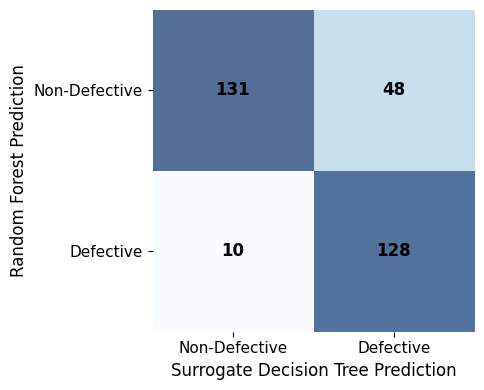

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Confusion matrix values
cm = np.array([[131, 48],
               [10, 128]])

labels = ['Non-Defective', 'Defective']

fig, ax = plt.subplots(figsize=(5, 4))

# Light blue colormap
im = ax.imshow(cm, cmap='Blues', alpha=0.7)

# Axis ticks and labels
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

ax.set_xlabel('Surrogate Decision Tree Prediction', fontsize=12)
ax.set_ylabel('Random Forest Prediction', fontsize=12)

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                fontsize=12, color='black', fontweight='bold')

# Clean look
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
